Testing CNN model

In [116]:
import tensorflow as tf
import pandas as pd


from keras import Sequential, layers, callbacks, applications, optimizers
from keras.preprocessing import image_dataset_from_directory

Preprocess data and create the training and validation split 80% / 20%.

In [ ]:
img_height = 299
img_width = 299

batch_size = 64

seed = 123

input_shape = [img_height,img_width, 3]
# 3 for rgb 
data_dir = "../../data/tests/flower_photos"

split = 0.2

ds_train = image_dataset_from_directory(
    data_dir,
    validation_split=split,
    seed=seed,
    subset="training",
    image_size=(img_height,img_width),
    batch_size=batch_size
)
ds_valid= image_dataset_from_directory(
    data_dir,
    validation_split=split,
    seed=seed,
    subset="validation",
    image_size=(img_height,img_width),
    batch_size=batch_size
)


class_names = ds_valid.class_names
num_classes = 5

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [118]:
%%capture
for image_batch, labels_batch in ds_train:
  print(image_batch.shape)
  print(labels_batch.shape)
  break

In [119]:
AUTOTUNE = tf.data.AUTOTUNE

ds_train = ds_train.cache().prefetch(buffer_size=AUTOTUNE)
ds_valid = ds_valid.cache().prefetch(buffer_size=AUTOTUNE)

In [ ]:
body = applications.Xception(weights="imagenet")
body.trainable = False

model_layers = [
    layers.Rescaling(1./255),
    
    layers.RandomFlip(mode="vertical_and_horizontal", seed=seed),
    layers.RandomRotation(0.2),
    
    body,
    
    # Classifier head
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    #layers.BatchNormalization(),
    #layers.Dropout(0.2),
    layers.Dense(num_classes, activation="softmax"),
]

In [121]:
model = Sequential(layers=model_layers)

early_stopping = callbacks.EarlyStopping(patience=5,
                                      min_delta=0.001,restore_best_weights=True)

optimizer = optimizers.Adam(learning_rate=1e-4)

model.compile(
    optimizer=optimizer,
    loss="sparse_categorical_crossentropy",
    metrics=['sparse_categorical_accuracy']
)

Train the model

In [122]:
history = model.fit(
    ds_train,
    validation_data=ds_valid,
    callbacks=[early_stopping],
    epochs=200,
)

Epoch 1/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 25s 239ms/step - loss: 1.5944 - sparse_categorical_accuracy: 0.3563 - val_loss: 1.5847 - val_sparse_categorical_accuracy: 0.4223
Epoch 2/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 206ms/step - loss: 1.5829 - sparse_categorical_accuracy: 0.4118 - val_loss: 1.5709 - val_sparse_categorical_accuracy: 0.4550
Epoch 3/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 206ms/step - loss: 1.5702 - sparse_categorical_accuracy: 0.4356 - val_loss: 1.5561 - val_sparse_categorical_accuracy: 0.4796
Epoch 4/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 206ms/step - loss: 1.5574 - sparse_categorical_accuracy: 0.4489 - val_loss: 1.5407 - val_sparse_categorical_accuracy: 0.5082
Epoch 5/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 19s 208ms/step - loss: 1.5431 - sparse_categorical_accuracy: 0.4584 - val_loss: 1.5247 - val_sparse_categorical_accuracy: 0.5191
Epoch 6/200
92/92 ━━━━━━━━━━━━━━━━━━━━ 18s 198ms/step - loss: 1.5282 - sparse_categorical_accuracy: 0.4755 - val_loss: 1.5073 - val_sparse_categorical_accuracy:

<Axes: >

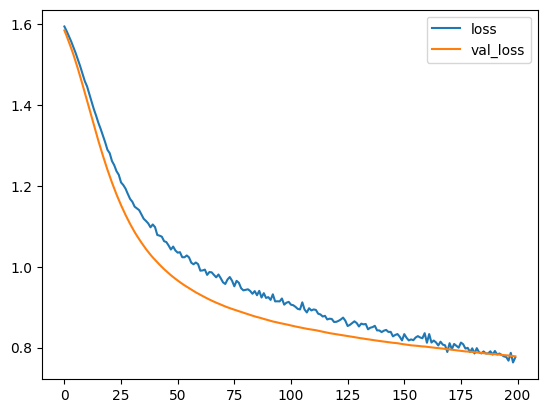

In [123]:

history_df = pd.DataFrame(history.history)
history_df.loc[:, ['loss', 'val_loss']].plot()

In [124]:
model.summary()

Model: "sequential_13"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_13 (Rescaling)        │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_flip_10 (RandomFlip)     │ (None, 299, 299, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ random_rotation_7               │ (None, 299, 299, 3)    │             0 │
│ (RandomRotation)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ xception (Functional)           │ (None, 1000)           │    22,910,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 1000)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_26 (Dense)                │ (None, 32)             │        32,032 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 5)              │           165 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,007,073 (87.77 MB)

 Trainable params: 32,197 (125.77 KB)

 Non-trainable params: 22,910,480 (87.40 MB)

 Optimizer params: 64,396 (251.55 KB)